In [1]:
!pip install -q segmentation-models-pytorch timm albumentations opencv-python matplotlib pillow

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.8/154.8 kB 5.6 MB/s eta 0:00:00


In [2]:
!git clone https://github.com/ultralytics/yolov5
%cd yolov5
!pip install -qr requirements.txt

Cloning into 'yolov5'...
remote: Enumerating objects: 17851, done.
remote: Counting objects: 100% (50/50), done.
remote: Compressing objects: 100% (40/40), done.
remote: Total 17851 (delta 34), reused 12 (delta 10), pack-reused 17801 (from 3)
Receiving objects: 100% (17851/17851), 16.98 MiB | 26.50 MiB/s, done.
Resolving deltas: 100% (12165/12165), done.
/content/yolov5
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 51.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 131.6/131.6 kB 10.5 MB/s eta 0:00:00


In [4]:
import os
import time
import cv2
import torch
import numpy as np
import matplotlib.pyplot as plt

from PIL import Image
import torch.nn.functional as F
import segmentation_models_pytorch as smp

In [5]:
IMAGE_PATH = "/content/test_image.jpg"

if not os.path.exists(IMAGE_PATH):
    raise FileNotFoundError(f"Image not found: {IMAGE_PATH}")

print("Using image:", IMAGE_PATH)

Using image: /content/test_image.jpg


In [6]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cpu


In [7]:
NUM_CLASSES = 19

CITYSCAPES_CLASSES = [
    'road', 'sidewalk', 'building', 'wall', 'fence', 'pole',
    'traffic light', 'traffic sign', 'vegetation', 'terrain',
    'sky', 'person', 'rider', 'car', 'truck', 'bus',
    'train', 'motorcycle', 'bicycle'
]

CITYSCAPES_COLORS = np.array([
    [128,  64, 128],  # road
    [244,  35, 232],  # sidewalk
    [ 70,  70,  70],  # building
    [102, 102, 156],  # wall
    [190, 153, 153],  # fence
    [153, 153, 153],  # pole
    [250, 170,  30],  # traffic light
    [220, 220,   0],  # traffic sign
    [107, 142,  35],  # vegetation
    [152, 251, 152],  # terrain
    [ 70, 130, 180],  # sky
    [220,  20,  60],  # person
    [255,   0,   0],  # rider
    [  0,   0, 142],  # car
    [  0,   0,  70],  # truck
    [  0,  60, 100],  # bus
    [  0,  80, 100],  # train
    [  0,   0, 230],  # motorcycle
    [119,  11,  32],  # bicycle
], dtype=np.uint8)

Original image shape: (319, 480, 3)


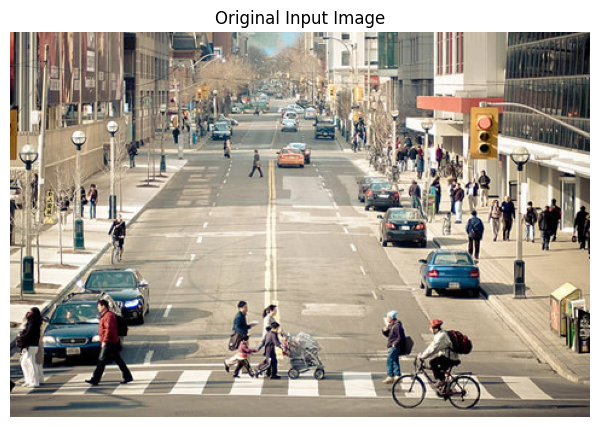

In [8]:
image = Image.open(IMAGE_PATH).convert("RGB")
image_np = np.array(image)
orig_h, orig_w = image_np.shape[:2]

print("Original image shape:", image_np.shape)

plt.figure(figsize=(8,5))
plt.imshow(image_np)
plt.title("Original Input Image")
plt.axis("off")
plt.show()

In [9]:
yolo_model = torch.hub.load('ultralytics/yolov5', 'yolov5s', pretrained=True)
yolo_model.conf = 0.25
yolo_model.to(device)
yolo_model.eval()

print("YOLOv5 model loaded successfully.")

/usr/local/lib/python3.12/dist-packages/torch/hub.py:247: UserWarning: You are about to download and run code from an untrusted repository. In a future release, this won't be allowed. To add the repository to your trusted list, change the command to load(..., trust_repo=False) and a command prompt will appear asking for an explicit confirmation of trust, or load(..., trust_repo=True), which will assume that the prompt is to be answered with 'yes'. You can also use load(..., trust_repo='check') which will only prompt for confirmation if the repo is not already trusted. This will eventually be the default behaviour
  _check_repo_is_trusted(


Downloading: "https://github.com/ultralytics/yolov5/zipball/master" to /root/.cache/torch/hub/master.zip
Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


YOLOv5 🚀 2026-3-23 Python-3.12.13 torch-2.10.0+cpu CPU

100%|██████████| 14.1M/14.1M [00:00<00:00, 322MB/s]

Fusing layers... 
YOLOv5s summary: 213 layers, 7225885 parameters, 0 gradients, 16.4 GFLOPs
Adding AutoShape... 


YOLOv5 model loaded successfully.


In [10]:
deeplab_model = smp.DeepLabV3Plus(
    encoder_name="resnet50",
    encoder_weights="imagenet",
    in_channels=3,
    classes=NUM_CLASSES,
    activation=None
).to(device)

checkpoint_path = "/content/deeplabv3plus_cityscapes.pth"

if os.path.exists(checkpoint_path):
    checkpoint = torch.load(checkpoint_path, map_location=device)

    if isinstance(checkpoint, dict) and "state_dict" in checkpoint:
        state_dict = checkpoint["state_dict"]
    else:
        state_dict = checkpoint

    cleaned_state_dict = {}
    for k, v in state_dict.items():
        new_k = k.replace("module.", "")
        cleaned_state_dict[new_k] = v

    deeplab_model.load_state_dict(cleaned_state_dict, strict=False)
    print("Loaded checkpoint:", checkpoint_path)
else:
    print("WARNING: No checkpoint found.")
    print("The code will still run, but segmentation quality may be poor unless you upload your trained .pth file.")

deeplab_model.eval()

config.json:   0%|          | 0.00/156 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/102M [00:00<?, ?B/s]

The code will still run, but segmentation quality may be poor unless you upload your trained .pth file.


DeepLabV3Plus(
  (encoder): ResNetEncoder(
    (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu): ReLU(inplace=True)
    (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (layer1): Sequential(
      (0): Bottleneck(
        (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu): ReLU(inplace=True)
        (downsample): Sequentia

In [11]:
def preprocess_for_deeplab(image_np, input_size=512):
    image_resized = cv2.resize(image_np, (input_size, input_size))
    image_resized = image_resized.astype(np.float32) / 255.0

    mean = np.array([0.485, 0.456, 0.406], dtype=np.float32)
    std  = np.array([0.229, 0.224, 0.225], dtype=np.float32)

    image_norm = (image_resized - mean) / std
    image_tensor = torch.tensor(image_norm).permute(2, 0, 1).unsqueeze(0).float().to(device)

    return image_tensor

In [12]:
# warm-up
_ = yolo_model(image)

start_yolo = time.time()
yolo_results = yolo_model(image)
end_yolo = time.time()

yolo_time = end_yolo - start_yolo
yolo_fps = 1.0 / yolo_time if yolo_time > 0 else 0

print(f"YOLOv5 inference time: {yolo_time*1000:.2f} ms")
print(f"YOLOv5 FPS: {yolo_fps:.2f}")

/root/.cache/torch/hub/ultralytics_yolov5_master/models/common.py:899: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with amp.autocast(autocast):
/root/.cache/torch/hub/ultralytics_yolov5_master/models/common.py:899: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with amp.autocast(autocast):


YOLOv5 inference time: 268.32 ms
YOLOv5 FPS: 3.73


In [13]:
yolo_render = yolo_results.render()[0]   # returns image with boxes
yolo_render_rgb = cv2.cvtColor(yolo_render, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(8,5))
plt.imshow(yolo_render_rgb)
plt.title("YOLOv5 Detection Output")
plt.axis("off")
plt.show()

In [14]:
detections_df = yolo_results.pandas().xyxy[0]
print(detections_df)
print("\nNumber of detected objects:", len(detections_df))

          xmin        ymin        xmax        ymax  confidence  class  \
0   337.913116  180.515945  393.014313  219.968903    0.856295      2   
1   316.263275  266.378174  389.615875  312.554626    0.850421      1   
2     3.496894  224.824005   28.562761  297.943604    0.839399      0   
3    62.540157  218.483780  101.395866  294.645935    0.817665      0   
4   379.324921   63.197575  404.894196  105.419090    0.810542      9   
5   305.397278  144.818390  345.459137  178.464157    0.799395      2   
6   377.043915  146.781387  392.477997  189.296982    0.756380      0   
7    53.012012  194.172958  116.472542  241.623550    0.748669      2   
8   360.769257  246.192078  383.281067  266.388794    0.675546     24   
9   221.039474   91.943207  246.209335  112.452126    0.671094      2   
10  166.714737   72.310234  185.007782   88.926384    0.645359      2   
11  307.047729  230.309235  330.900635  288.727509    0.639086      0   
12  288.415405  119.833359  322.317841  148.055496 

In [15]:
image_tensor = preprocess_for_deeplab(image_np, input_size=512)

# warm-up
with torch.no_grad():
    _ = deeplab_model(image_tensor)

start_seg = time.time()
with torch.no_grad():
    logits = deeplab_model(image_tensor)
end_seg = time.time()

seg_time = end_seg - start_seg
seg_fps = 1.0 / seg_time if seg_time > 0 else 0

print(f"DeepLabV3+ inference time: {seg_time*1000:.2f} ms")
print(f"DeepLabV3+ FPS: {seg_fps:.2f}")

DeepLabV3+ inference time: 2172.40 ms
DeepLabV3+ FPS: 0.46


In [16]:
upsampled_logits = F.interpolate(
    logits,
    size=(orig_h, orig_w),
    mode="bilinear",
    align_corners=False
)

pred_mask = upsampled_logits.argmax(dim=1)[0].cpu().numpy().astype(np.uint8)

print("Prediction mask shape:", pred_mask.shape)
print("Predicted class IDs:", np.unique(pred_mask))

Prediction mask shape: (319, 480)
Predicted class IDs: [ 0  6 12 16]


In [17]:
color_mask = CITYSCAPES_COLORS[pred_mask]
seg_overlay = (0.6 * image_np + 0.4 * color_mask).astype(np.uint8)

plt.figure(figsize=(14,5))

plt.subplot(1,2,1)
plt.imshow(color_mask)
plt.title("DeepLabV3+ Predicted Mask")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(seg_overlay)
plt.title("DeepLabV3+ Overlay")
plt.axis("off")

plt.tight_layout()
plt.show()

In [18]:
present_ids = np.unique(pred_mask)

print("Classes predicted in the image:")
for class_id in present_ids:
    if 0 <= class_id < len(CITYSCAPES_CLASSES):
        print(f"{class_id:2d}: {CITYSCAPES_CLASSES[class_id]}")

Classes predicted in the image:
 0: road
 6: traffic light
12: rider
16: train


In [19]:
fused_image = seg_overlay.copy()

for _, row in detections_df.iterrows():
    x1, y1, x2, y2 = int(row["xmin"]), int(row["ymin"]), int(row["xmax"]), int(row["ymax"])
    label = f'{row["name"]} {row["confidence"]:.2f}'

    cv2.rectangle(fused_image, (x1, y1), (x2, y2), (0, 255, 0), 2)
    cv2.putText(
        fused_image,
        label,
        (x1, max(y1 - 10, 20)),
        cv2.FONT_HERSHEY_SIMPLEX,
        0.5,
        (255, 255, 255),
        2,
        cv2.LINE_AA
    )

plt.figure(figsize=(10,6))
plt.imshow(fused_image)
plt.title("Combined Pipeline Output (YOLOv5 + DeepLabV3+)")
plt.axis("off")
plt.show()

In [20]:
total_pipeline_time = yolo_time + seg_time
combined_fps = 1.0 / total_pipeline_time if total_pipeline_time > 0 else 0

print(f"YOLOv5 time       : {yolo_time*1000:.2f} ms")
print(f"DeepLabV3+ time   : {seg_time*1000:.2f} ms")
print(f"Total pipeline    : {total_pipeline_time*1000:.2f} ms")
print(f"Combined FPS      : {combined_fps:.2f}")

YOLOv5 time       : 268.32 ms
DeepLabV3+ time   : 2172.40 ms
Total pipeline    : 2440.72 ms
Combined FPS      : 0.41


In [21]:
Image.fromarray(yolo_render_rgb).save("/content/yolo_output.png")
Image.fromarray(color_mask).save("/content/deeplab_mask.png")
Image.fromarray(seg_overlay).save("/content/deeplab_overlay.png")
Image.fromarray(fused_image).save("/content/combined_pipeline_output.png")

print("Saved:")
print("/content/yolo_output.png")
print("/content/deeplab_mask.png")
print("/content/deeplab_overlay.png")
print("/content/combined_pipeline_output.png")

Saved:
/content/yolo_output.png
/content/deeplab_mask.png
/content/deeplab_overlay.png
/content/combined_pipeline_output.png


In [22]:
print("="*50)
print("COMBINED PIPELINE EVALUATION SUMMARY")
print("="*50)
print(f"Detected objects           : {len(detections_df)}")
print(f"YOLOv5 inference time      : {yolo_time*1000:.2f} ms")
print(f"DeepLabV3+ inference time  : {seg_time*1000:.2f} ms")
print(f"Total pipeline time        : {total_pipeline_time*1000:.2f} ms")
print(f"Combined pipeline FPS      : {combined_fps:.2f}")
print(f"Segmentation classes found : {[CITYSCAPES_CLASSES[i] for i in present_ids if i < len(CITYSCAPES_CLASSES)]}")
print("="*50)

COMBINED PIPELINE EVALUATION SUMMARY
Detected objects           : 36
YOLOv5 inference time      : 268.32 ms
DeepLabV3+ inference time  : 2172.40 ms
Total pipeline time        : 2440.72 ms
Combined pipeline FPS      : 0.41
Segmentation classes found : ['road', 'traffic light', 'rider', 'train']


In [23]:
gt_mask_path = "/content/mask.png"

def compute_iou_per_class(pred, target, num_classes):
    ious = []
    for cls in range(num_classes):
        pred_inds = (pred == cls)
        target_inds = (target == cls)

        intersection = np.logical_and(pred_inds, target_inds).sum()
        union = np.logical_or(pred_inds, target_inds).sum()

        if union == 0:
            ious.append(np.nan)
        else:
            ious.append(intersection / union)
    return ious

if os.path.exists(gt_mask_path):
    gt_mask = np.array(Image.open(gt_mask_path))

    if gt_mask.ndim == 3:
        gt_h, gt_w, _ = gt_mask.shape
        class_mask = np.zeros((gt_h, gt_w), dtype=np.int32)

        for class_id, color in enumerate(CITYSCAPES_COLORS):
            same = np.all(gt_mask == color, axis=-1)
            class_mask[same] = class_id

        gt_mask = class_mask

    if gt_mask.shape != pred_mask.shape:
        gt_mask = cv2.resize(
            gt_mask.astype(np.int32),
            (pred_mask.shape[1], pred_mask.shape[0]),
            interpolation=cv2.INTER_NEAREST
        )

    ious = compute_iou_per_class(pred_mask.astype(np.int32), gt_mask.astype(np.int32), NUM_CLASSES)
    miou = np.nanmean(ious)

    print("\nPer-class IoU:")
    for i, iou in enumerate(ious):
        class_name = CITYSCAPES_CLASSES[i]
        if np.isnan(iou):
            print(f"{i:2d} ({class_name:15s}): N/A")
        else:
            print(f"{i:2d} ({class_name:15s}): {iou:.4f}")

    print(f"\nMean IoU (mIoU): {miou:.4f}")
else:
    print("No ground-truth mask found, so mIoU was not computed.")


Per-class IoU:
 0 (road           ): 0.1452
 1 (sidewalk       ): N/A
 2 (building       ): N/A
 3 (wall           ): N/A
 4 (fence          ): N/A
 5 (pole           ): N/A
 6 (traffic light  ): 0.0000
 7 (traffic sign   ): N/A
 8 (vegetation     ): N/A
 9 (terrain        ): N/A
10 (sky            ): N/A
11 (person         ): N/A
12 (rider          ): 0.0000
13 (car            ): N/A
14 (truck          ): N/A
15 (bus            ): N/A
16 (train          ): 0.0000
17 (motorcycle     ): N/A
18 (bicycle        ): N/A

Mean IoU (mIoU): 0.0363
